In [1]:
!pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.9/554.9 kB 2.6 MB/s  0:00:00
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [2]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
from IPython.display import display
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

# Download required NLTK resources
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

# Initialize stemming and lemmatization objects
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/17f50d36-54d6-4c27-a64f-
[nltk_data]     e7f6ec902d19/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /home/17f50d36-54d6-4c27-a64f-
[nltk_data]     e7f6ec902d19/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /home/17f50d36-54d6-4c27-a64f-
[nltk_data]     e7f6ec902d19/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [3]:
def preprocess_review(review):
    review = review.lower() # Convert to lowercase
    review = re.sub(r'[^\w\s]', '', review) # Remove punctuations
    review = re.sub(r'\d+', '', review) # Remove numbers
    
    tokens = word_tokenize(review) # Tokenize words
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words] # Remove stopwords
    
    # Perform stemming and lemmatization
    stemmed_tokens = [stemmer.stem(word) for word in tokens]
    lemmatized_tokens = [lemmatizer.lemmatize(word) for word in tokens]
    
    return ' '.join(lemmatized_tokens) # Join tokens into a single string

# Read the CSV file and preprocess
df_simple = pd.read_csv('simple_dataset.csv')
df_simple['preprocessed_text'] = df_simple['text'].apply(preprocess_review)
display(df_simple.head())

,category,text,preprocessed_text
0,Positive,I love this product! It works great and has ex...,love product work great excellent quality
1,Negative,Terrible experience. The product broke after o...,terrible experience product broke one use
2,Positive,Fantastic! I would highly recommend this to ev...,fantastic would highly recommend everyone
3,Negative,Awful. It was a complete waste of money.,awful complete waste money
4,Positive,Amazing product! Very satisfied with my purchase.,amazing product satisfied purchase


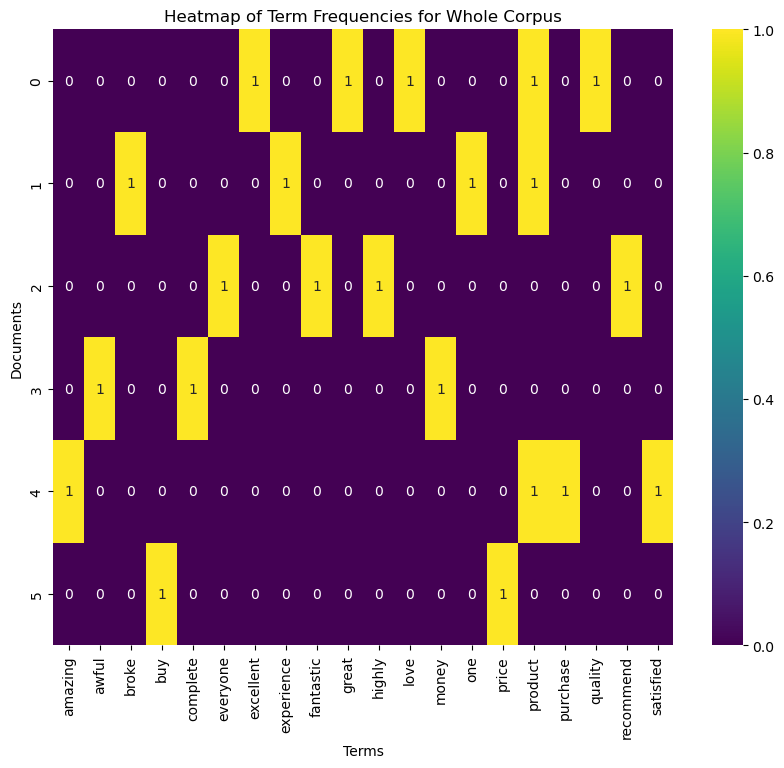

In [4]:
# Create Document-Term Matrix
vectorizer = CountVectorizer(max_features=20)
X = vectorizer.fit_transform(df_simple['preprocessed_text'])
term_freq_matrix = X.toarray()
terms = vectorizer.get_feature_names_out()

# Create Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(term_freq_matrix, xticklabels=terms, cmap='viridis', annot=True)
plt.title("Heatmap of Term Frequencies for Whole Corpus")
plt.xlabel("Terms")
plt.ylabel("Documents")
plt.show()

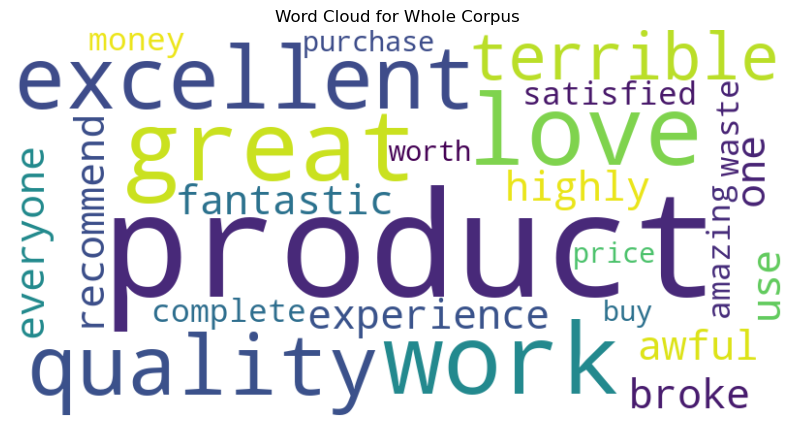

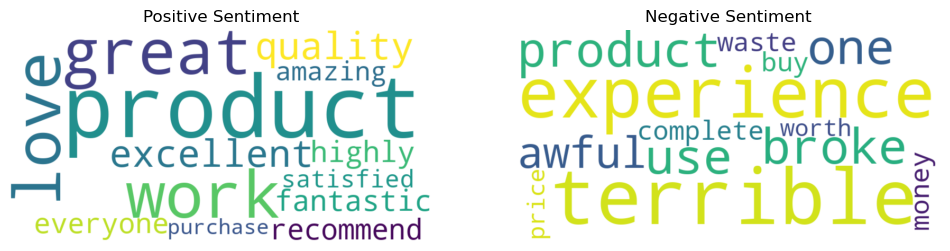

In [5]:
# Word Cloud for Whole Corpus
all_text = ' '.join(df_simple['preprocessed_text'])
wordcloud = WordCloud(width=800, height=400, max_words=100, background_color='white').generate(all_text)

plt.figure(figsize=(10, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud for Whole Corpus")
plt.show()

# Generate word clouds for positive and negative sentiments
pos_text = ' '.join(df_simple[df_simple['category'] == 'Positive']['preprocessed_text'])
pos_wc = WordCloud(width=800, height=400, background_color='white').generate(pos_text)

neg_text = ' '.join(df_simple[df_simple['category'] == 'Negative']['preprocessed_text'])
neg_wc = WordCloud(width=800, height=400, background_color='white').generate(neg_text)

# Display side by side
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(pos_wc, interpolation='bilinear')
plt.title('Positive Sentiment')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(neg_wc, interpolation='bilinear')
plt.title('Negative Sentiment')
plt.axis('off')
plt.show()

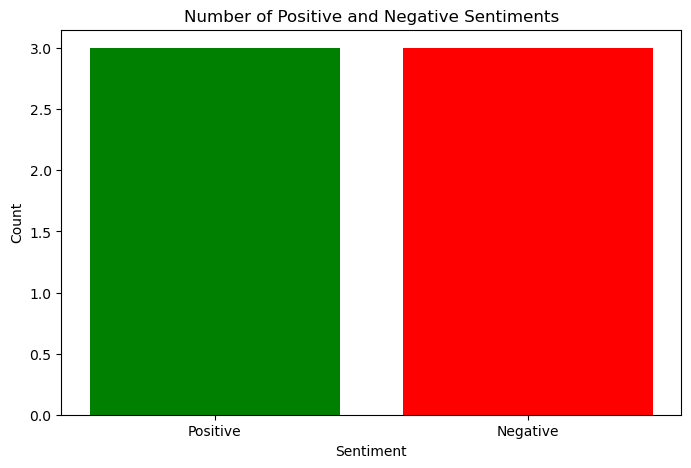

In [6]:
sentiment_counts = df_simple['category'].value_counts()
plt.figure(figsize=(8, 5))
plt.bar(sentiment_counts.index, sentiment_counts.values, color=['green', 'red'])
plt.title('Number of Positive and Negative Sentiments')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

In [14]:
# The exact path based on your screenshot
df_real = pd.read_csv(r'restaurant_reviews.csv')

df_real['preprocessed_text'] = df_real['Review'].apply(preprocess_review)
display(df_real.head())

,Review,Sentiment,Category,Topics,preprocessed_text
0,I love the cozy atmosphere of this place. The ...,Positive,Dining Experience,"atmosphere, pizza, staff",love cozy atmosphere place pizza delicious sta...
1,The sushi at this place was terrible. It was b...,Negative,Food,sushi,sushi place terrible bland poorly cooked wont ...
2,I love the cozy atmosphere of this place. The ...,Positive,Dining Experience,"atmosphere, pasta, staff",love cozy atmosphere place pasta delicious sta...
3,The salad at this place was decent. Nothing ex...,Neutral,Food,salad,salad place decent nothing exceptional nothing...
4,This hotel was alright. The sushi was nothing ...,Neutral,Dining Experience,sushi,hotel alright sushi nothing special wasnt bad ...


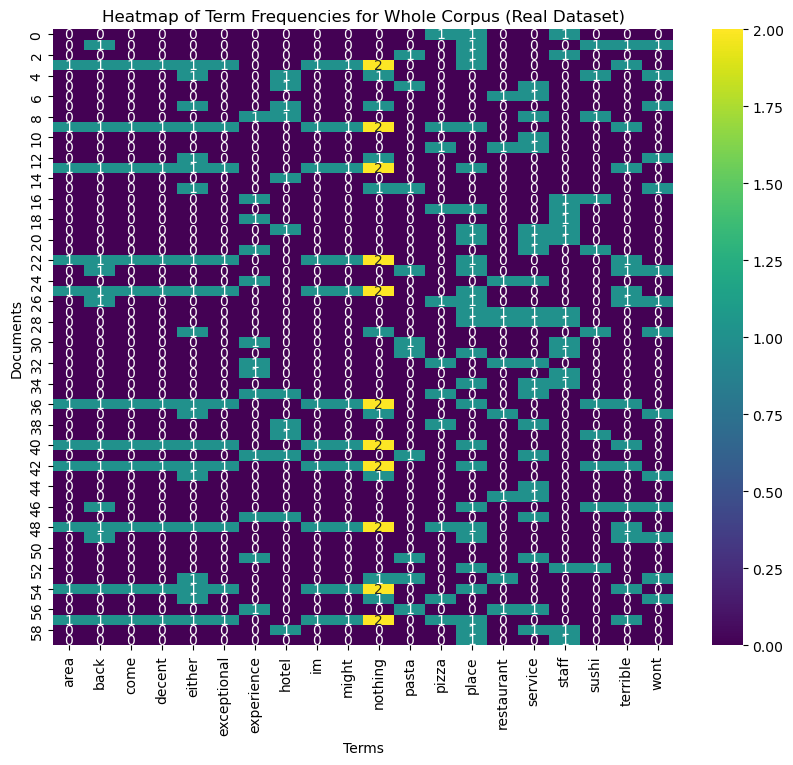

In [15]:
vectorizer_real = CountVectorizer(max_features=20)
X_real = vectorizer_real.fit_transform(df_real['preprocessed_text'])
term_freq_matrix_real = X_real.toarray()
terms_real = vectorizer_real.get_feature_names_out()

plt.figure(figsize=(10, 8))
sns.heatmap(term_freq_matrix_real, xticklabels=terms_real, cmap='viridis', annot=True)
plt.title("Heatmap of Term Frequencies for Whole Corpus (Real Dataset)")
plt.xlabel("Terms")
plt.ylabel("Documents")
plt.show()

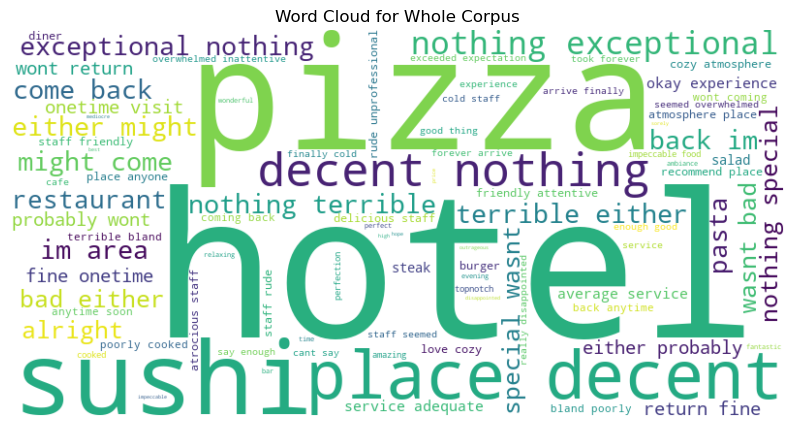

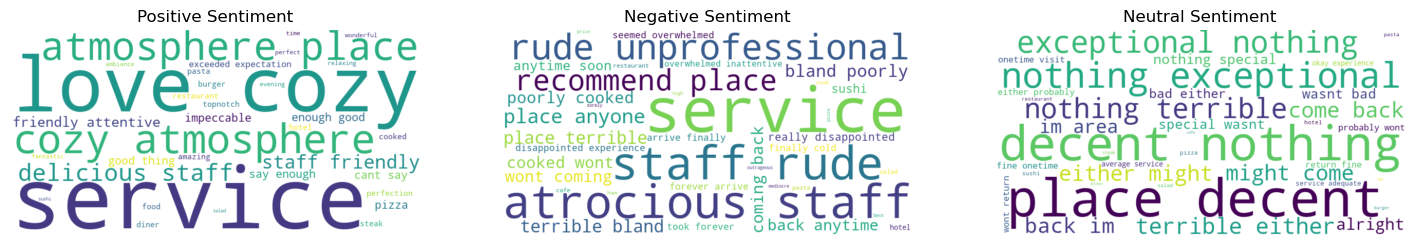

In [16]:
# Word Cloud for Whole Corpus
all_text_real = ' '.join(df_real['preprocessed_text'])
wordcloud_real = WordCloud(width=800, height=400, max_words=100, background_color='white').generate(all_text_real)

plt.figure(figsize=(10, 8))
plt.imshow(wordcloud_real, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud for Whole Corpus")
plt.show()

# Sentiments: Positive, Negative, Neutral
pos_real = ' '.join(df_real[df_real['Sentiment'] == 'Positive']['preprocessed_text'])
pos_wc_real = WordCloud(width=800, height=400, background_color='white').generate(pos_real)

neg_real = ' '.join(df_real[df_real['Sentiment'] == 'Negative']['preprocessed_text'])
neg_wc_real = WordCloud(width=800, height=400, background_color='white').generate(neg_real)

neu_real = ' '.join(df_real[df_real['Sentiment'] == 'Neutral']['preprocessed_text'])
neu_wc_real = WordCloud(width=800, height=400, background_color='white').generate(neu_real)

# Display the three word clouds
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
plt.imshow(pos_wc_real, interpolation='bilinear')
plt.title('Positive Sentiment')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(neg_wc_real, interpolation='bilinear')
plt.title('Negative Sentiment')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(neu_wc_real, interpolation='bilinear')
plt.title('Neutral Sentiment')
plt.axis('off')
plt.show()

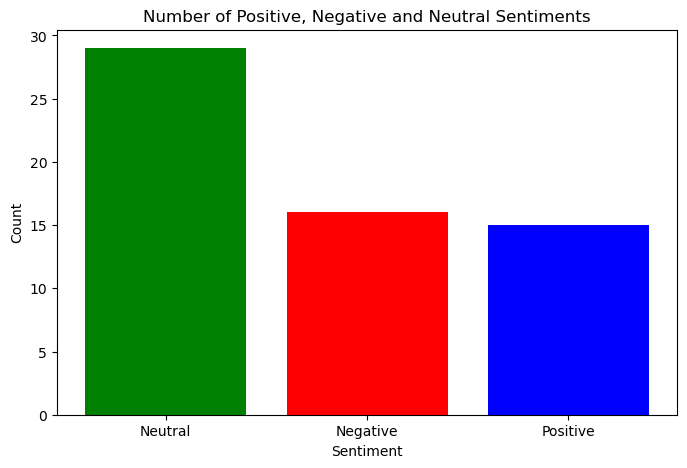

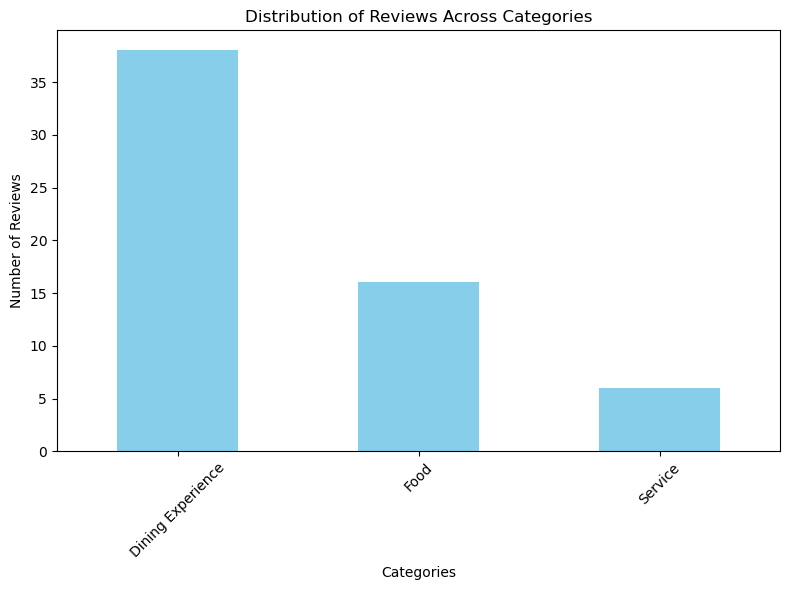

In [17]:
# Sentiment Bar Chart
sentiment_counts_real = df_real['Sentiment'].value_counts()
plt.figure(figsize=(8, 5))
plt.bar(sentiment_counts_real.index, sentiment_counts_real.values, color=['green', 'red', 'blue'])
plt.title('Number of Positive, Negative and Neutral Sentiments')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

# Category Distribution Chart
category_counts = df_real['Category'].value_counts()
plt.figure(figsize=(8, 6))
category_counts.plot(kind='bar', color='skyblue')
plt.xlabel('Categories')
plt.ylabel('Number of Reviews')
plt.title('Distribution of Reviews Across Categories')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

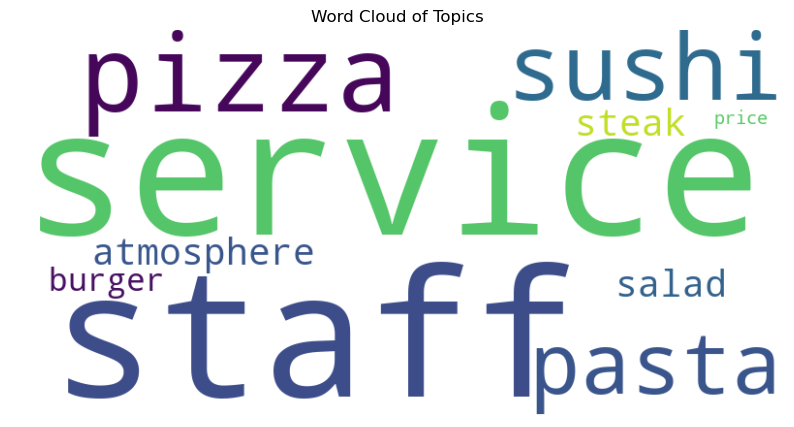

In [18]:
# Flatten the list of topics
all_topics = [topic for topics in df_real['Topics'].dropna().str.split(', ') for topic in topics]
topic_counts = Counter(all_topics)

# Generate word cloud from topic frequencies
topic_wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(topic_counts)

plt.figure(figsize=(10, 8))
plt.imshow(topic_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Topics')
plt.show()